In [1]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/raw/brfss_2021")

df_2021 = pd.read_csv(
    DATA_PATH / "diabetes_binary_health_indicators_BRFSS2021.csv"
)

print("Dataset shape:", df_2021.shape)

df_2021.head()

Dataset shape: (236378, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,0,1.0,1,15.0,1.0,0.0,0.0,0,1,...,1,0.0,5.0,10.0,20.0,0.0,0,11,4.0,5.0
1,1.0,1,0.0,1,28.0,0.0,0.0,1.0,0,1,...,1,0.0,2.0,0.0,0.0,0.0,0,11,4.0,3.0
2,1.0,1,1.0,1,33.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,10.0,0.0,0.0,0,9,4.0,7.0
3,1.0,0,1.0,1,29.0,0.0,1.0,1.0,1,1,...,1,0.0,5.0,0.0,30.0,1.0,1,12,3.0,4.0
4,0.0,0,0.0,1,24.0,1.0,0.0,0.0,0,0,...,1,0.0,3.0,0.0,0.0,1.0,1,13,5.0,6.0


In [2]:
print(df_2021.info())

print("\nMissing values:")
print(df_2021.isnull().sum().sort_values(ascending=False).head(10))

print("\nTarget distribution:")
print(
    df_2021["Diabetes_binary"]
    .value_counts(normalize=True)
    .mul(100)
)

<class 'pandas.DataFrame'>
RangeIndex: 236378 entries, 0 to 236377
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       236378 non-null  float64
 1   HighBP                236378 non-null  int64  
 2   HighChol              236378 non-null  float64
 3   CholCheck             236378 non-null  int64  
 4   BMI                   236378 non-null  float64
 5   Smoker                236378 non-null  float64
 6   Stroke                236378 non-null  float64
 7   HeartDiseaseorAttack  236378 non-null  float64
 8   PhysActivity          236378 non-null  int64  
 9   Fruits                236378 non-null  int64  
 10  Veggies               236378 non-null  int64  
 11  HvyAlcoholConsump     236378 non-null  int64  
 12  AnyHealthcare         236378 non-null  int64  
 13  NoDocbcCost           236378 non-null  float64
 14  GenHlth               236378 non-null  float64
 15  MentHlth   

In [3]:
expected_features = [
    'HighBP',
    'HighChol',
    'CholCheck',
    'BMI',
    'Smoker',
    'Stroke',
    'HeartDiseaseorAttack',
    'PhysActivity',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'AnyHealthcare',
    'NoDocbcCost',
    'GenHlth',
    'MentHlth',
    'PhysHlth',
    'DiffWalk',
    'Sex',
    'Age',
    'Education',
    'Income'
]

target = "Diabetes_binary"

In [4]:
dataset_features = [
    col for col in df_2021.columns
    if col != target
]

missing_features = set(expected_features) - set(dataset_features)
extra_features = set(dataset_features) - set(expected_features)

print("Expected features:", len(expected_features))
print("2021 features:", len(dataset_features))

print("\nMissing features:")
print(missing_features)

print("\nExtra features:")
print(extra_features)

Expected features: 21
2021 features: 21

Missing features:
set()

Extra features:
set()


In [5]:
# Check duplicates in BRFSS 2021
duplicate_count_2021 = df_2021.duplicated().sum()

print("Original shape:", df_2021.shape)
print("Exact duplicate rows:", duplicate_count_2021)

# Remove exact duplicates
df_2021_clean = df_2021.drop_duplicates().copy()

print("\nAfter removing duplicates:", df_2021_clean.shape)
print("Rows removed:", len(df_2021) - len(df_2021_clean))

Original shape: (236378, 22)
Exact duplicate rows: 13135

After removing duplicates: (223243, 22)
Rows removed: 13135


In [6]:
print("Original target distribution:")
print(
    df_2021["Diabetes_binary"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("\nAfter duplicate removal:")
print(
    df_2021_clean["Diabetes_binary"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

Original target distribution:
Diabetes_binary
0.0    85.799017
1.0    14.200983
Name: proportion, dtype: float64

After duplicate removal:
Diabetes_binary
0.0    85.040964
1.0    14.959036
Name: proportion, dtype: float64


In [7]:
X_2021 = df_2021_clean[expected_features].copy()
y_2021 = df_2021_clean["Diabetes_binary"].copy()

# Ensure feature order is exactly the same
X_2021 = X_2021[expected_features]

print("X_2021 shape:", X_2021.shape)
print("y_2021 shape:", y_2021.shape)

print("\nFeature order:")
print(list(X_2021.columns))

X_2021 shape: (223243, 21)
y_2021 shape: (223243,)

Feature order:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [9]:
print("Expected feature order:")
print(expected_features)

print("\nBRFSS 2021 feature order:")
print(list(X_2021.columns))

print(
    "\nFeature order matches:",
    expected_features == list(X_2021.columns)
)

Expected feature order:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

BRFSS 2021 feature order:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Feature order matches: True


In [10]:
try:
    print(final_calibrated_model)
except NameError:
    print("Model is not loaded in this notebook.")

Model is not loaded in this notebook.


In [11]:
import joblib
from pathlib import Path

MODEL_PATH = Path("../../Model_Pickle_Files/final_calibrated_model.pkl")

final_calibrated_model = joblib.load(MODEL_PATH)

print("Model loaded successfully!")
print(type(final_calibrated_model))

Model loaded successfully!
<class 'sklearn.calibration.CalibratedClassifierCV'>


In [12]:
import numpy as np

y_2021_proba = final_calibrated_model.predict_proba(X_2021)[:, 1]

print("Number of predictions:", len(y_2021_proba))
print("Minimum probability:", y_2021_proba.min())
print("Maximum probability:", y_2021_proba.max())
print("Average probability:", y_2021_proba.mean())

Number of predictions: 223243
Minimum probability: 0.0
Maximum probability: 1.0
Average probability: 0.13905598203932307


In [13]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

roc_auc_2021 = roc_auc_score(
    y_2021,
    y_2021_proba
)

pr_auc_2021 = average_precision_score(
    y_2021,
    y_2021_proba
)

brier_2021 = brier_score_loss(
    y_2021,
    y_2021_proba
)

print(f"BRFSS 2021 External ROC-AUC: {roc_auc_2021:.4f}")
print(f"BRFSS 2021 External PR-AUC: {pr_auc_2021:.4f}")
print(f"BRFSS 2021 External Brier Score: {brier_2021:.4f}")

BRFSS 2021 External ROC-AUC: 0.8124
BRFSS 2021 External PR-AUC: 0.4225
BRFSS 2021 External Brier Score: 0.1048


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

THRESHOLD = 0.24

y_2021_pred = (
    y_2021_proba >= THRESHOLD
).astype(int)

accuracy_2021 = accuracy_score(
    y_2021,
    y_2021_pred
)

precision_2021 = precision_score(
    y_2021,
    y_2021_pred,
    zero_division=0
)

recall_2021 = recall_score(
    y_2021,
    y_2021_pred,
    zero_division=0
)

f1_2021 = f1_score(
    y_2021,
    y_2021_pred,
    zero_division=0
)

print(f"Threshold: {THRESHOLD}")
print(f"Accuracy:  {accuracy_2021:.4f}")
print(f"Precision: {precision_2021:.4f}")
print(f"Recall:    {recall_2021:.4f}")
print(f"F1 Score:  {f1_2021:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_2021, y_2021_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_2021,
        y_2021_pred,
        target_names=["No Diabetes", "Diabetes"]
    )
)

Threshold: 0.24
Accuracy:  0.8035
Precision: 0.3908
Recall:    0.5612
F1 Score:  0.4607

Confusion Matrix:
[[160628  29220]
 [ 14654  18741]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.92      0.85      0.88    189848
    Diabetes       0.39      0.56      0.46     33395

    accuracy                           0.80    223243
   macro avg       0.65      0.70      0.67    223243
weighted avg       0.84      0.80      0.82    223243



In [15]:
comparison = pd.DataFrame([
    {
        "Dataset": "BRFSS 2015 Test",
        "ROC-AUC": 0.8297,
        "PR-AUC": 0.4300,
        "Brier Score": 0.0968,
        "Accuracy": 0.8138,
        "Precision": 0.3900,
        "Recall": 0.5956,
        "F1 Score": 0.4713
    },
    {
        "Dataset": "BRFSS 2021 External",
        "ROC-AUC": roc_auc_2021,
        "PR-AUC": pr_auc_2021,
        "Brier Score": brier_2021,
        "Accuracy": accuracy_2021,
        "Precision": precision_2021,
        "Recall": recall_2021,
        "F1 Score": f1_2021
    }
])

comparison

,Dataset,ROC-AUC,PR-AUC,Brier Score,Accuracy,Precision,Recall,F1 Score
0,BRFSS 2015 Test,0.829700,0.43000,0.09680,0.81380,0.390000,0.595600,0.471300
1,BRFSS 2021 External,0.812391,0.42252,0.10483,0.80347,0.390755,0.561192,0.460716


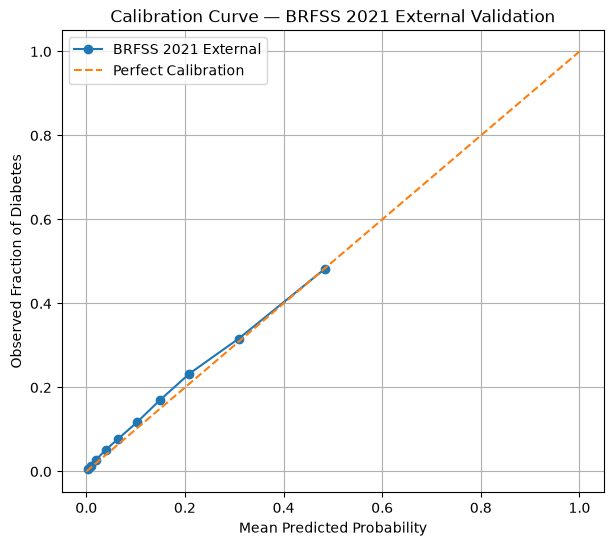

In [16]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_2021,
    y_2021_proba,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="BRFSS 2021 External"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraction of Diabetes")
plt.title("Calibration Curve — BRFSS 2021 External Validation")

plt.legend()
plt.grid(True)

plt.show()

In [17]:
calibration_results = pd.DataFrame({
    "Mean Predicted Probability": prob_pred,
    "Observed Diabetes Rate": prob_true,
    "Difference": prob_true - prob_pred
})

calibration_results

,Mean Predicted Probability,Observed Diabetes Rate,Difference
0,0.002977,0.006486,0.003509
1,0.009432,0.012944,0.003511
2,0.019473,0.027532,0.008059
3,0.039270,0.051422,0.012152
4,0.064465,0.077540,0.013074
5,0.103095,0.117608,0.014513
6,0.149758,0.170437,0.020679
7,0.209201,0.233038,0.023837
8,0.308750,0.316117,0.007367
9,0.484402,0.483135,-0.001267


In [18]:
import joblib
import json
from pathlib import Path

MODEL_DIR = Path("../model_artifacts")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [19]:
joblib.dump(
    final_calibrated_model,
    MODEL_DIR / "diabetes_risk_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [20]:
FEATURE_ORDER = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "BMI",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "GenHlth",
    "MentHlth",
    "PhysHlth",
    "DiffWalk",
    "Sex",
    "Age",
    "Education",
    "Income"
]

with open(MODEL_DIR / "feature_order.json", "w") as f:
    json.dump(FEATURE_ORDER, f, indent=4)

print("Feature order saved!")

Feature order saved!


In [21]:
MODEL_CONFIG = {
    "model_name": "HistGradientBoostingClassifier",
    "calibration": "Isotonic",
    "screening_threshold": 0.24,
    "target": "Diabetes_binary",
    "model_version": "1.0",
    "training_dataset": "BRFSS 2015",
    "external_validation_dataset": "BRFSS 2021"
}

with open(MODEL_DIR / "model_config.json", "w") as f:
    json.dump(MODEL_CONFIG, f, indent=4)

print("Model configuration saved!")

Model configuration saved!


In [22]:
from pathlib import Path

MODEL_DIR = Path("../../Backend/Model_Pickle_Files")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(MODEL_DIR.resolve())

C:\Users\dell\Desktop\Personal projects\Hackathon Project\Backend\Model_Pickle_Files


In [23]:
print("Model directory:")
print(MODEL_DIR.resolve())

Model directory:
C:\Users\dell\Desktop\Personal projects\Hackathon Project\Backend\Model_Pickle_Files


In [24]:
import joblib

joblib.dump(
    final_calibrated_model,
    MODEL_DIR / "diabetes_risk_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [25]:
import json

FEATURE_ORDER = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "BMI",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "GenHlth",
    "MentHlth",
    "PhysHlth",
    "DiffWalk",
    "Sex",
    "Age",
    "Education",
    "Income"
]

with open(MODEL_DIR / "feature_order.json", "w") as f:
    json.dump(FEATURE_ORDER, f, indent=4)

print("Feature order saved!")

Feature order saved!


In [26]:
MODEL_CONFIG = {
    "model_name": "HistGradientBoostingClassifier",
    "calibration": "Isotonic",
    "screening_threshold": 0.24,
    "target": "Diabetes_binary",
    "model_version": "1.0",
    "training_dataset": "BRFSS 2015",
    "external_validation_dataset": "BRFSS 2021"
}

with open(MODEL_DIR / "model_config.json", "w") as f:
    json.dump(MODEL_CONFIG, f, indent=4)

print("Model configuration saved!")

Model configuration saved!
